# Tutorial 6: Aligning spatial transcriptomics data to H&E image of human breast cancer data from Xenium 

## Data Preparation

Please download the required data files from the provided link:
[Download here](https://pan.baidu.com/s/17K1cmxOPmhSvV6dG6gnafw?pwd=sjbx)

- `rep1.h5ad`
- `rep2_HE.png`

After downloading, place both files into the `datasets` folder located in the same directory as this notebook.

The folder structure should be organized as follows:

```
project_root/
│
├── datasets/
│   └── HBC/
│       ├── rep1.h5ad
│       └── rep2_HE.png
│
├── Tutorial6_Aligning_spatial_transcriptomics_data_to_H&E_image_of_human_breast_cancer_data_from_Xenium.ipynb
│
└── SpaMOMA/
```

## import packages

In [1]:
from SpaMOMA.SpaMOMA import SpaMOMA

## Specify Slice Metadata

In [2]:
save_directory = "./SpaMOMA_output/HBC/"  
spamoma = SpaMOMA(save_dir=save_directory)
spamoma.add_slice(
    sample_id="rep1",  
    raw_data_path="./datasets/HBC/rep1.h5ad",  
    feature="rna"  
)
spamoma.add_slice(
    sample_id="rep2_HE",  
    raw_data_path="./datasets/HBC/rep2_HE.png",  
    feature="img"  
)
spamoma.set_reference('rep2_HE')

In [3]:
print(f"aligning {[sid for sid in spamoma.input_slice_dict.keys() if sid != spamoma.reference_sample_id]} to {spamoma.reference_sample_id}")

aligning ['rep1'] to rep2_HE


## Data Preprocessing

preprocessing rna features...


------Calculating spatial graph...


The graph contains 1148000 edges, 164000 cells.
7.0000 neighbors per cell on average.


Size of Input:  (164000, 313)


2026-02-18 22:34:14.492281: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-02-18 22:34:14.498985: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled



100%|██████████| 500/500 [16:01<00:00,  1.92s/it]

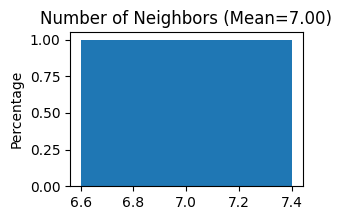

In [4]:
spamoma.preprocess_input_slices({
    'rep2_HE':{
        'downsample':False
    }
})

## Generate Spatial Pattern Images

generating spatial pattern image... gaussian_sigma:0.8, interpolation_method:linear, max_distance_ratio"1.2


saving image...


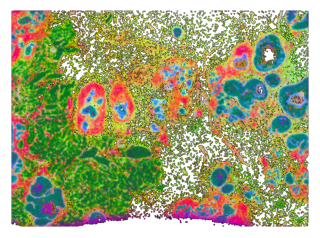

Img for rep1 is saved to ./SpaMOMA_output/HBC/rep1/RGB.png


Original image saved to: ./SpaMOMA_output/HBC/rep2_HE/RGB.png


In [5]:
spamoma.generate_imgs({
    'rep1':{
        'gaussian_sigma':0.8,
        'max_distance_ratio':1.2, 
    }
})

In [6]:
spamoma.input_slice_dict

{'rep1': {'sample_id': 'rep1',
  'raw_data_path': './datasets/HBC/rep1.h5ad',
  'feature': 'rna',
  'pseudo_color_key': 'pca',
  'processed_data': AnnData object with n_obs × n_vars = 164000 × 313
      obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_counts', 'image_col', 'image_row', 'spot', 'img_x', 'img_y', 'spot_x', 'spot_y', 'batch', 'my_pixel_x', 'my_pixel_y'
      var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns: 'log1p', 'hvg', 'spatial_neighbors', 'moranI'
      obsm: 'he', 'image_coor', 'spatial', 'pca'
      layers: 'raw'
      obsp: 'spatial_connectivities', 'spatial_distances',
  'SPI_path': './SpaMOMA_output/HBC/rep1/RGB.png'},
 'rep2_HE': {'sample_id': 'rep2_HE',
  'raw_data_path': './datasets/HBC/rep2_HE.png',
  'feature': 'img',
  'SPI_path': './SpaMOMA_output/HBC/rep2_HE/RGB.png'

## Model Training

In [7]:
spamoma.train(coarse_epochs=1000,fine_epochs=300,parallel_mode=True,coarse_gpu=1,fine_gpu=2)

start coarse adaptation...


start fine adaptation...


fine adaptation done!
coarse adaptation done!


## Slice Alignment

rep2_HE image saved to: ./SpaMOMA_output/HBC//alignment_output/rep2_HE.png
****************** aligning rep1 to rep2_HE ..... ******************
start coarse alignment...
match params: {'model_key': 'roma', 'match_threshold': 0.999, 'extract_max_keypoints': 4096, 'force_resize': True, 'image_height': 560, 'image_width': 560, 'choice_geometry_type': 'Homography'}
Loading Roma model: ./SpaMOMA_output/HBC/coarse_model/adapted_model_epoch_1000.pth
current Roma instance ID: 132339205561792
preprocessing is already resized
Force resize to 560x560


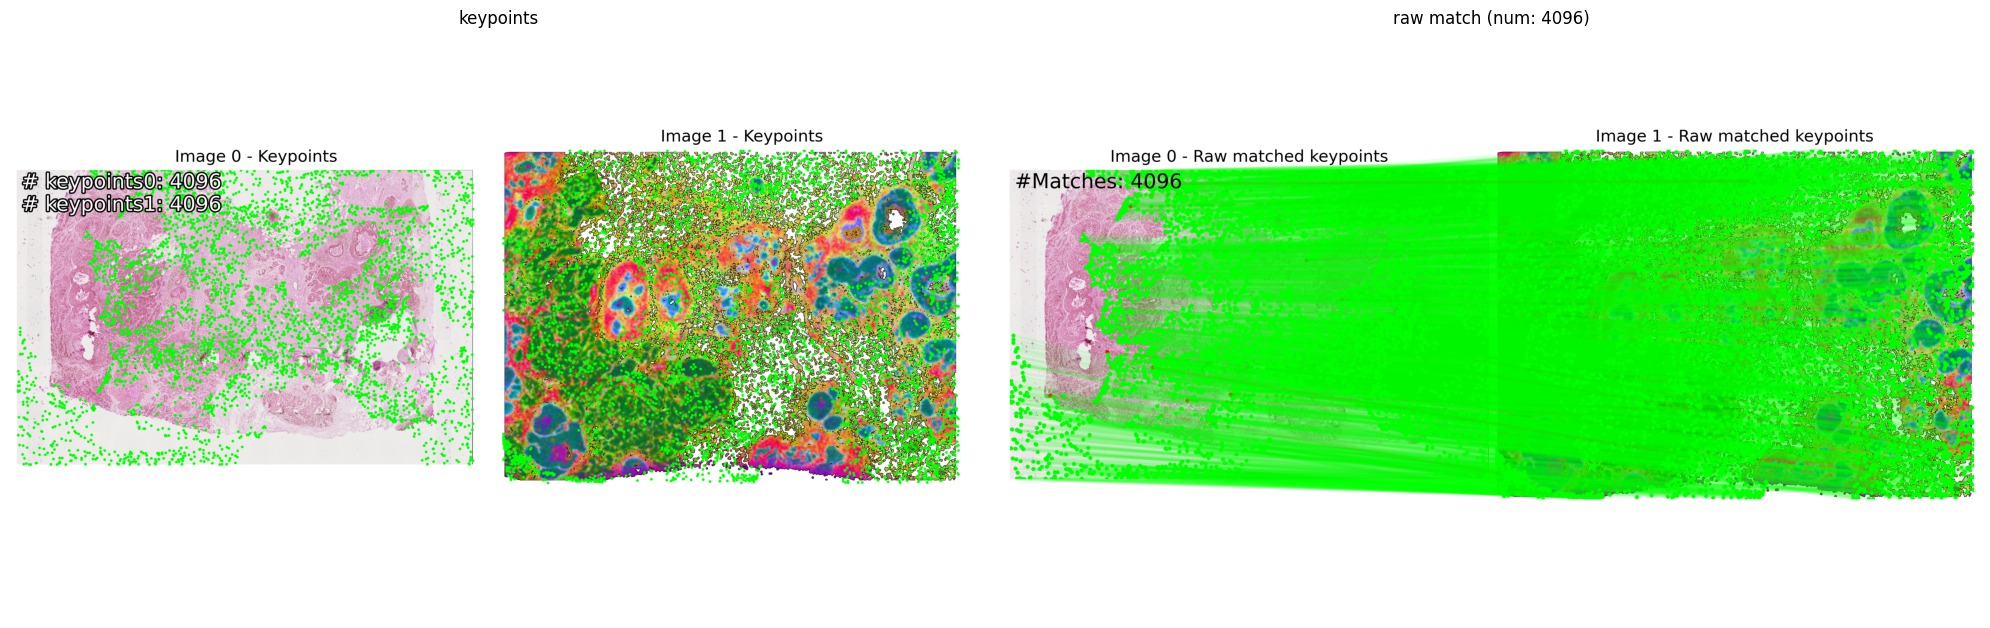


Matching statistics:
- Number of raw match points: 4096
coarse alignment done!
start fine alignment...
Loading Roma model: ./SpaMOMA_output/HBC/fine_model/adapted_model_epoch_300.pth
current Roma instance ID: 132335705568016
preprocessing is already resized
Force resize to 560x560


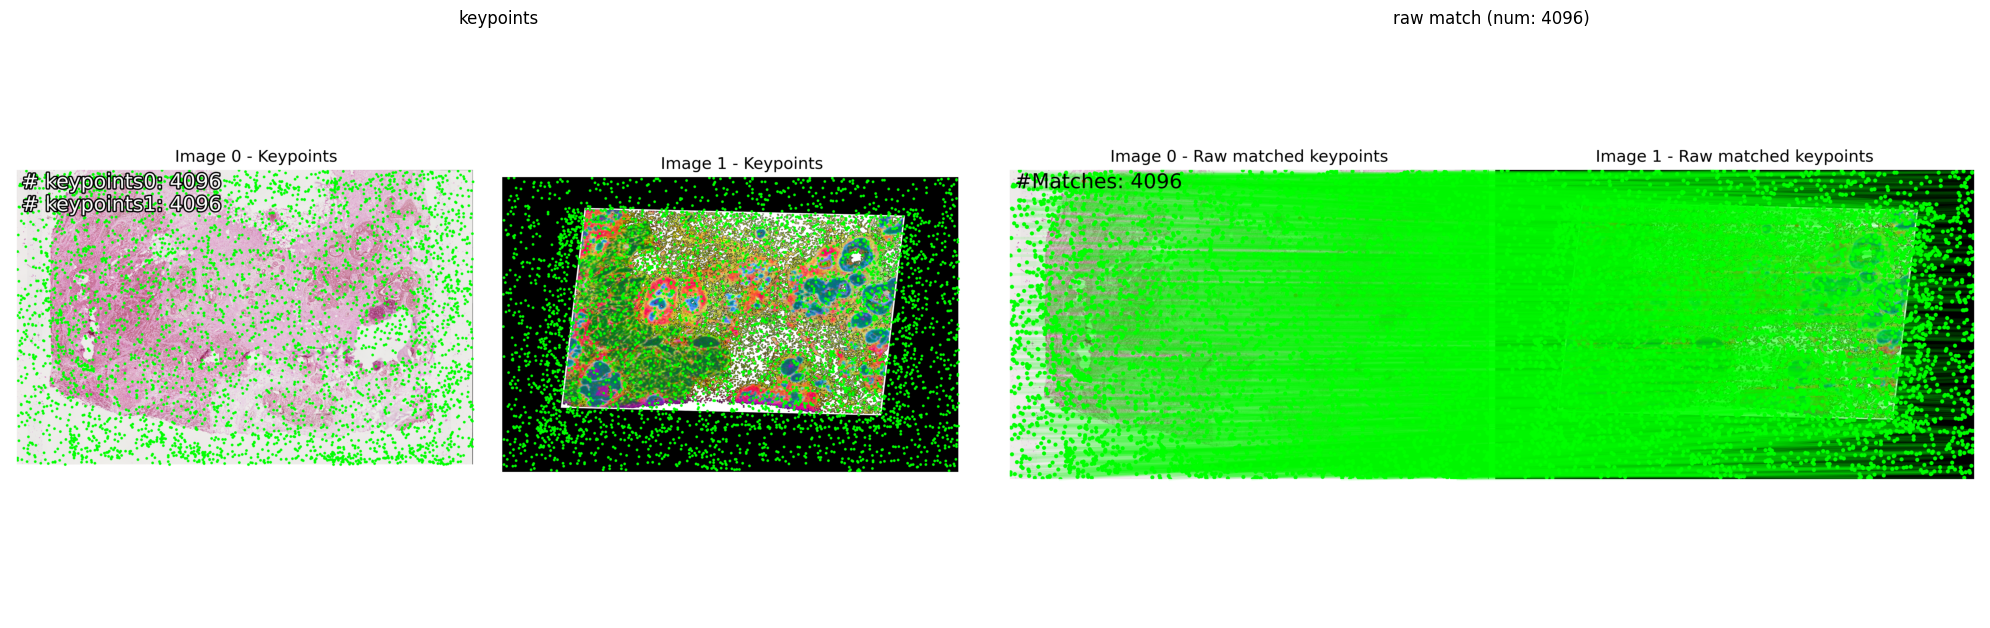


Matching statistics:
- Number of raw match points: 4096


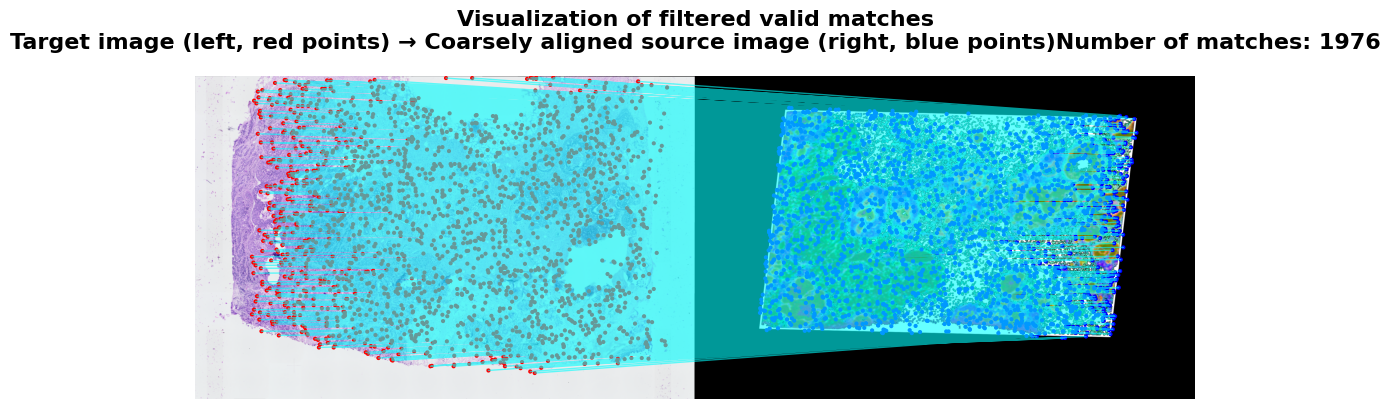

aligned rep1 adata is saved to: ./SpaMOMA_output/HBC//alignment_output/rep1.h5ad
fine alignment done!


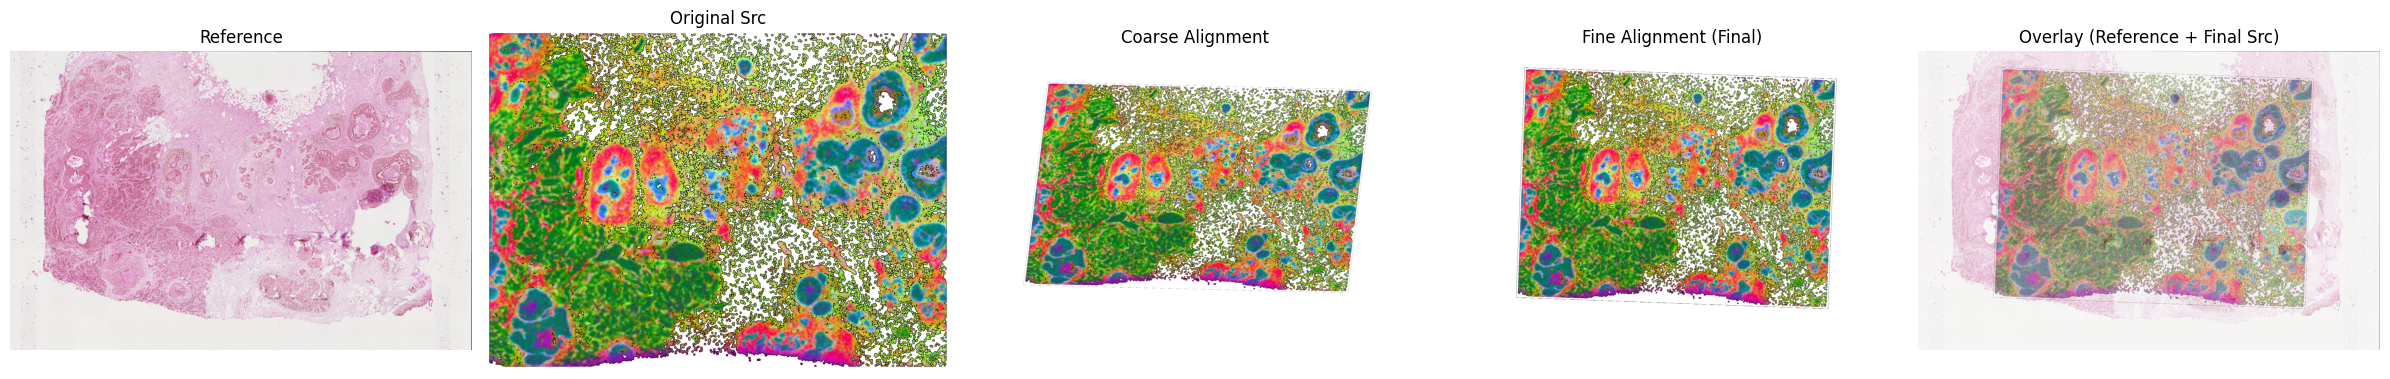

In [ ]:
spamoma.align_slices(visualize_correspondences=True)

## Visualize Alignment Results

Overlaying aligned slice for sample: rep1


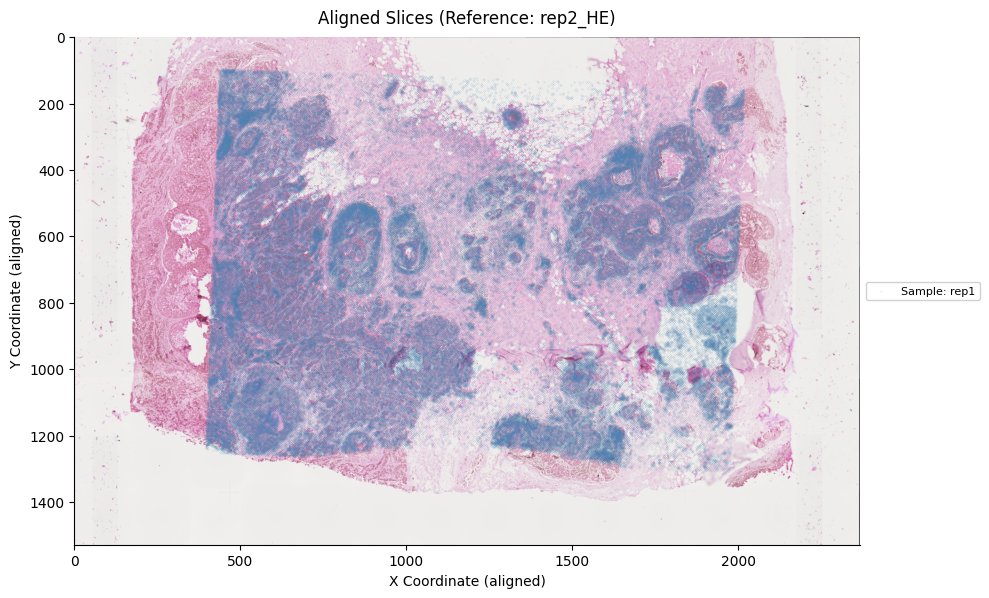

In [ ]:
spamoma.visualize_aligned_slices(figsize=(10,10),point_size=0.01)